In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
class BVP:
    def __init__(self, patient, quadrant, signal, features, id):
        self.patient = patient
        self.quadrant = quadrant
        self.signal = signal
        self.features = features
        self.id = id

MAX_VID_LENGTH = 100

In [5]:
patients = list(range(1, 62))
patients.remove(23)

quadrants = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

In [6]:
bvp_path = "../BVPs"

failed_masks = [
    [2, "Q1_1"],
    [52, "Q7_2"],
    [53, "Q4_2"]
]

In [7]:
# AROUSAL

def get_label(path):
    q = path.split("_")[0]

    if q in ["Q1", "Q2", "Q3"]:
        return "High Arousal"
    
    if q in ["Q4", "Q5", "Q6"]:
        return "Neutral Arousal"
    
    else:
        return "Low Arousal"

In [8]:
def cut_bvp(bvp, t_start, t_end, fs=60):
    n = len(bvp)

    # Convert time to sample indices
    n_start = int(t_start * fs)
    n_end = int(t_end * fs)

    # Clamp to valid range
    n_start = max(0, min(n_start, n))
    n_end = max(0, min(n_end, n))

    return bvp[n_start:n_end]

In [9]:
def cut_relevant_bvp(data, quadrant, fs=60):

    if quadrant == "Q1_2":

        data = cut_bvp(data, 20, MAX_VID_LENGTH, fs)

    elif quadrant == "Q3_2":

        data = cut_bvp(data, 38, MAX_VID_LENGTH, fs)
    
    return data


In [10]:
def cut_relevant_au(df, quadrant):

    if quadrant == "Q1_2":

        df = df[(df[" timestamp"] >= 20) & (df[" timestamp"] <= MAX_VID_LENGTH)]

    elif quadrant == "Q3_2":

        df = df[(df[" timestamp"] >= 38) & (df[" timestamp"] <= MAX_VID_LENGTH)]
    
    return df


In [11]:
BVPs = []

fs = 60

for patient in patients:

    for quadrant in quadrants:

        if [patient, quadrant] in failed_masks:
            print(f"Skipping Patient_{patient}, {quadrant}")
            continue

        data = np.load(f"{bvp_path}/Patient_{patient}/{quadrant}.npy")

        data = cut_relevant_bvp(data, quadrant, fs)

        id = f"{patient}{quadrant}"

        bvp = BVP(patient, quadrant, data, [], id)

        BVPs.append(bvp)

        #print(f"Patient_{patient}, {quadrant}: {data.shape}")

print(f"Loaded {len(BVPs)} BVP signals")

Skipping Patient_2, Q1_1
Skipping Patient_52, Q7_2
Skipping Patient_53, Q4_2
Loaded 1077 BVP signals


In [12]:
from scipy.signal import find_peaks, czt

In [13]:
def compute_bvp_features_article(bvp_signal, fs, patient=None, quadrant=None):
    """
    Compute PPG features (14 features from paper) using CZT.
    Includes debug prints when something fails.
    """

    bvp = np.asarray(bvp_signal)

    if len(bvp) < fs * 2:
        print(f"[SHORT SIGNAL] Patient {patient}, {quadrant}")
        return None

    # ---- Remove DC ----
    bvp = bvp - np.mean(bvp)

    features = {}

    # --------------------------------------------------
    # 1. Peak detection → RR intervals
    # --------------------------------------------------
    min_dist = int(0.4 * fs)
    peaks, _ = find_peaks(bvp, distance=min_dist)

    if len(peaks) < 3:
        print(f"[PEAK DETECTION FAILED] Patient {patient}, {quadrant}")
        return None

    rr = np.diff(peaks) / fs
    hr = 60.0 / rr

    # --------------------------------------------------
    # 2. HR features
    # --------------------------------------------------
    features["hr_mean"] = np.mean(hr)
    features["hr_std"] = np.std(hr)

    # --------------------------------------------------
    # 3. HRV time-domain features
    # --------------------------------------------------
    features["rr_mean"] = np.mean(rr)
    features["rr_std"] = np.std(rr)

    diff_rr = np.diff(rr)

    if len(diff_rr) > 0:
        features["rmssd"] = np.sqrt(np.mean(diff_rr ** 2))
        features["sdsd"] = np.std(diff_rr)
        features["pnn50"] = np.sum(np.abs(diff_rr) > 0.05) / len(diff_rr)
    else:
        print(f"[RR DIFFERENCES FAILED] Patient {patient}, {quadrant}")
        features["rmssd"] = np.nan
        features["sdsd"] = np.nan
        features["pnn50"] = np.nan

    # --------------------------------------------------
    # 4. TINN
    # --------------------------------------------------
    try:
        hist, bin_edges = np.histogram(rr, bins=20)
        features["tinn"] = bin_edges[-1] - bin_edges[0]
    except Exception:
        print(f"[TINN FAILED] Patient {patient}, {quadrant}")
        features["tinn"] = np.nan

    # --------------------------------------------------
    # 5. Poincaré
    # --------------------------------------------------
    try:
        if len(diff_rr) > 0:
            sd1 = np.sqrt(np.var(diff_rr) / 2)
            sd2 = np.sqrt(2 * np.var(rr) - 0.5 * np.var(diff_rr))

            features["sd1"] = sd1
            features["sd2"] = sd2
            features["sd1_sd2"] = sd1 / sd2 if sd2 != 0 else np.nan
        else:
            raise ValueError
    except Exception:
        print(f"[POINCARE FAILED] Patient {patient}, {quadrant}")
        features["sd1"] = np.nan
        features["sd2"] = np.nan
        features["sd1_sd2"] = np.nan

    # --------------------------------------------------
    # 6. LF / HF using CZT
    # --------------------------------------------------
    try:
        rr_times = np.cumsum(rr)
        rr_times = np.insert(rr_times, 0, 0)

        fs_interp = 4.0
        t_uniform = np.arange(0, rr_times[-1], 1 / fs_interp)

        rr_interp = np.interp(
            t_uniform,
            rr_times,
            np.append(rr, rr[-1])
        )

        fmin = 0.04
        fmax = 0.4
        n_bins = 256

        w = np.exp(-1j * 2 * np.pi * (fmax - fmin) / (n_bins * fs_interp))
        a = np.exp(1j * 2 * np.pi * fmin / fs_interp)

        spectrum = czt(rr_interp, n_bins, w, a)
        power = np.abs(spectrum) ** 2
        freqs = np.linspace(fmin, fmax, n_bins)

        lf_band = (freqs >= 0.04) & (freqs < 0.15)
        hf_band = (freqs >= 0.15) & (freqs < 0.4)

        lf = np.sum(power[lf_band])
        hf = np.sum(power[hf_band])

        features["lf"] = lf
        features["hf"] = hf
        features["lf_hf"] = lf / hf if hf > 0 else np.nan

    except Exception:
        print(f"[LF/HF FAILED] Patient {patient}, {quadrant}")
        features["lf"] = np.nan
        features["hf"] = np.nan
        features["lf_hf"] = np.nan

    return features

In [14]:
def compute_au_features(patient, quadrant):

    path = rf"C:\Users\mique\OneDrive\Dokumenty\GitHub\POS\Gesture Emotion Prediction\Results\{patient}\{quadrant}\vid_crop.csv"

    df = pd.read_csv(path)

    # keep only valid frames
    if "success" in df.columns:
        df = df[df["success"] == 1]

    df = cut_relevant_au(df, quadrant)

    features = {}

    # select AU intensity columns
    au_cols = [c for c in df.columns if "_r" in c]

    for col in au_cols:
        features[f"{col}_mean"] = df[col].mean()
        # features[f"{col}_std"] = df[col].std()
        # features[f"{col}_max"] = df[col].max()

    # for col in au_cols:
    #     features[f"{col}_mean"] = df[col].mean()
    #     features[f"{col}_std"] = df[col].std()
    #     features[f"{col}_max"] = df[col].max()

    return features


In [15]:
valid = []
failed = []

for bvp in BVPs:  # use a copy to safely remove items

    print(f"Computing Features for Patient_{bvp.patient}...", end="\r", flush=True)

    patient = f"Patient_{bvp.patient}"
    
    try:
        # Use the new windowed feature extraction
        feats_bvp = compute_bvp_features_article(bvp.signal, fs, bvp.patient, bvp.quadrant)

        if feats_bvp is None or feats_bvp == []:
            print(f"Failed: Patient_{bvp.patient}, {bvp.quadrant}")
            failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
            BVPs.remove(bvp)  # remove problematic signal
            continue

        feats_au = compute_au_features(patient, bvp.quadrant)

        bvp.features = {**feats_bvp, **feats_au}
        
        valid.append(f"Patient_{bvp.patient}, {bvp.quadrant}")

    except Exception as e:
        print(f"Error for Patient_{bvp.patient}, {bvp.quadrant}: {e}")
        failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
        BVPs.remove(bvp)

print(f"Extracted features for {len(valid)} videos")
print(f"Failed: {failed}")

[SHORT SIGNAL] Patient 14, Q1_214...
Failed: Patient_14, Q1_2
[SHORT SIGNAL] Patient 60, Q3_260...
Failed: Patient_60, Q3_2
Extracted features for 1073 videos..
Failed: ['Patient_14, Q1_2', 'Patient_60, Q3_2']


In [16]:
bvp = BVPs[2]
fs = 60

print("Example of features: ", bvp.patient, bvp.quadrant)
print(bvp.features)

Example of features:  1 Q2_1
{'hr_mean': 100.53924015095781, 'hr_std': 34.28763822791599, 'rr_mean': 0.6719298245614036, 'rr_std': 0.22313026236660477, 'rmssd': 0.27916222455598755, 'sdsd': 0.27909225198677157, 'pnn50': 0.6607142857142857, 'tinn': 0.5666666666666667, 'sd1': 0.19734802395647086, 'sd2': 0.2462275074155119, 'sd1_sd2': 0.8014865033882819, 'lf': 7305.553035238854, 'hf': 5825.711057788672, 'lf_hf': 1.254019116768881, ' AU01_r_mean': 0.1215648854961832, ' AU02_r_mean': 0.06022900763358779, ' AU04_r_mean': 0.2837022900763359, ' AU05_r_mean': 0.040381679389312974, ' AU06_r_mean': 0.500737913486005, ' AU07_r_mean': 0.5524554707379135, ' AU09_r_mean': 0.0490754877014419, ' AU10_r_mean': 1.246458863443596, ' AU12_r_mean': 0.6728117048346056, ' AU14_r_mean': 0.6985156912637829, ' AU15_r_mean': 0.09681509754028839, ' AU17_r_mean': 0.24728583545377444, ' AU20_r_mean': 0.05957167090754877, ' AU23_r_mean': 0.05670907548770144, ' AU25_r_mean': 0.21196352841391009, ' AU26_r_mean': 0.3234

In [17]:
for bvp in BVPs:

    try:

        if (f"Patient_{bvp.patient}, {bvp.quadrant}") not in failed:
            feats = bvp.features
            #print(bvp.patient, bvp.quadrant)
            for jdx in range(0, 14):
                dummie =  list(feats.values())[jdx] == np.nan

    except Exception as e:

        print(f"Not loaded on Patient_{bvp.patient}, {bvp.quadrant}")


Not loaded on Patient_14, Q2_1
Not loaded on Patient_60, Q4_1


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectFpr, f_classif

In [19]:
X = []
y = []
groups = []

for bvp in BVPs:
    if bvp is None or bvp.features == []:
        print("Error: Patient", bvp.patient, bvp.quadrant)
        continue
    
    feat_values = list(bvp.features.values())
    X.append(feat_values)
    y.append(get_label(bvp.quadrant))
    groups.append(bvp.id)  
    

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)
print(np.unique(y, return_counts=True))
print("Example of data: ", X[0])

Error: Patient 14 Q2_1
Error: Patient 60 Q4_1
(1073, 31) (1073,)
(array(['High Arousal', 'Low Arousal', 'Neutral Arousal'], dtype='<U15'), array([356, 359, 358], dtype=int64))
Example of data:  [9.26717515e+01 2.87402265e+01 7.03645833e-01 1.83746427e-01
 2.14400891e-01 2.14333471e-01 7.41935484e-01 5.66666667e-01
 1.51556651e-01 2.11083113e-01 7.17995147e-01 5.94819513e+03
 3.30514666e+03 1.79967661e+00 2.83855685e-01 1.87120991e-01
 7.88090379e-01 4.27988338e-02 7.25284257e-01 3.66129738e-01
 5.77696793e-02 1.49075802e+00 9.42295918e-01 1.00930758e+00
 1.97623907e-01 2.99453353e-01 6.50728863e-02 8.96282799e-02
 2.64693878e-01 3.99409621e-01 4.23243440e-01]


In [20]:
from sklearn.feature_selection import f_classif
import numpy as np

# X = feature matrix (n_samples, n_features)
# y = labels

F_values, p_values = f_classif(X, y)

# Feature names (important!)
feature_names = list(BVPs[0].features.keys())

# Combine everything
anova_results = list(zip(feature_names, F_values, p_values))

# Sort by F-score (descending)
anova_results.sort(key=lambda x: x[1], reverse=True)

# Print nicely
for name, f, p in anova_results:
    print(f"{name:15} | F = {f:.3f} | p = {p:.5f}")

 AU09_r_mean    | F = 51.354 | p = 0.00000
 AU12_r_mean    | F = 32.848 | p = 0.00000
 AU06_r_mean    | F = 32.806 | p = 0.00000
 AU25_r_mean    | F = 31.360 | p = 0.00000
 AU23_r_mean    | F = 31.256 | p = 0.00000
 AU10_r_mean    | F = 21.667 | p = 0.00000
lf              | F = 20.221 | p = 0.00000
hf              | F = 17.535 | p = 0.00000
 AU07_r_mean    | F = 14.952 | p = 0.00000
 AU14_r_mean    | F = 10.202 | p = 0.00004
 AU17_r_mean    | F = 7.400 | p = 0.00064
 AU20_r_mean    | F = 7.103 | p = 0.00086
 AU26_r_mean    | F = 6.486 | p = 0.00159
 AU02_r_mean    | F = 6.346 | p = 0.00182
 AU05_r_mean    | F = 6.077 | p = 0.00237
tinn            | F = 4.795 | p = 0.00845
 AU01_r_mean    | F = 3.981 | p = 0.01895
lf_hf           | F = 1.847 | p = 0.15819
hr_std          | F = 1.735 | p = 0.17694
 AU45_r_mean    | F = 1.639 | p = 0.19468
sd2             | F = 1.378 | p = 0.25252
rr_std          | F = 1.362 | p = 0.25650
sdsd            | F = 1.213 | p = 0.29774
sd1             | F = 1.

In [21]:
feature_names = list(bvp.features.keys())

In [26]:
num_folds = 5
feat_p_cutoff = 0.2

In [27]:
from sklearn.feature_selection import SelectFpr, f_classif

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("anova", SelectFpr(score_func=f_classif, alpha=feat_p_cutoff)),  # FEATURE IMPORTANCE CUTOFF
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedGroupKFold(n_splits=num_folds)

classif_reports = []
conf_matrix = []
f1_scores = []

from collections import Counter
print("Class distribution:", Counter(y))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    print(f"Fold {fold}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    #print("Train dist:", Counter(y_train))
    #print("Test dist:", Counter(y_test))

    pipe.fit(X_train, y_train)

    # Access ANOVA step
    anova = pipe.named_steps["anova"]

    selected_mask = anova.get_support()
    selected_features = np.array(feature_names)[selected_mask]

    print("Selected features:", selected_features)
    #print("Num features:", len(selected_features))

    score = pipe.score(X_test, y_test)

    print("Score:", score)

    y_pred = pipe.predict(X_test)

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    classif_reports.append(classification_report(y_test, y_pred))
    conf_matrix.append(confusion_matrix(y_test, y_pred))
    f1_scores.append(report_dict["macro avg"]["f1-score"])

print("-"*50)

print("F1-Scores:", [f"{score:.2f}" for score in f1_scores])
print()
print('\033[1m' + f"Average F1-Score: {sum(f1_scores)/num_folds}" + '\033[0m')
print()
for idx in range(num_folds):
    print(classif_reports[idx])
    print(conf_matrix[idx])
    print()
    print("-"*50)

Class distribution: Counter({'Low Arousal': 359, 'Neutral Arousal': 358, 'High Arousal': 356})
Fold 0
Selected features: ['hr_std' 'tinn' 'sd2' 'lf' 'hf' 'lf_hf' ' AU01_r_mean' ' AU02_r_mean'
 ' AU05_r_mean' ' AU06_r_mean' ' AU07_r_mean' ' AU09_r_mean'
 ' AU10_r_mean' ' AU12_r_mean' ' AU14_r_mean' ' AU17_r_mean'
 ' AU20_r_mean' ' AU23_r_mean' ' AU25_r_mean' ' AU26_r_mean']
Score: 0.4558139534883721
Fold 1
Selected features: ['tinn' 'lf' 'hf' ' AU01_r_mean' ' AU02_r_mean' ' AU05_r_mean'
 ' AU06_r_mean' ' AU07_r_mean' ' AU09_r_mean' ' AU10_r_mean'
 ' AU12_r_mean' ' AU14_r_mean' ' AU17_r_mean' ' AU20_r_mean'
 ' AU23_r_mean' ' AU25_r_mean' ' AU26_r_mean' ' AU45_r_mean']
Score: 0.4558139534883721
Fold 2
Selected features: ['tinn' 'lf' 'hf' ' AU01_r_mean' ' AU02_r_mean' ' AU05_r_mean'
 ' AU06_r_mean' ' AU07_r_mean' ' AU09_r_mean' ' AU10_r_mean'
 ' AU12_r_mean' ' AU14_r_mean' ' AU17_r_mean' ' AU20_r_mean'
 ' AU23_r_mean' ' AU25_r_mean' ' AU26_r_mean']
Score: 0.43457943925233644
Fold 3
Selecte

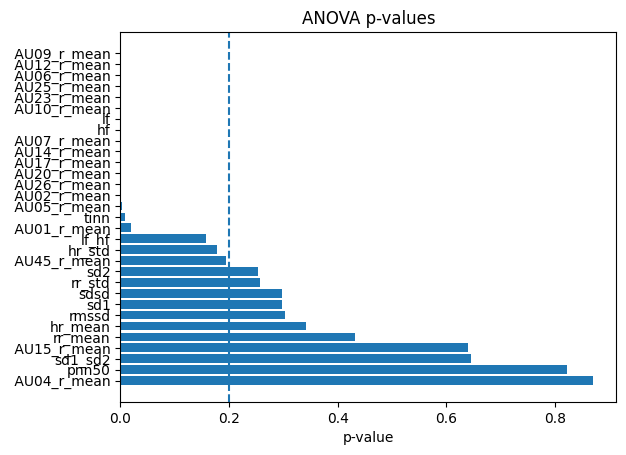

In [30]:
p_vals = [x[2] for x in anova_results]

plt.figure()
plt.barh(names, p_vals)
plt.xlabel("p-value")
plt.title("ANOVA p-values")
plt.gca().invert_yaxis()

# Optional: significance line
plt.axvline(x=feat_p_cutoff, linestyle='--')
plt.show()

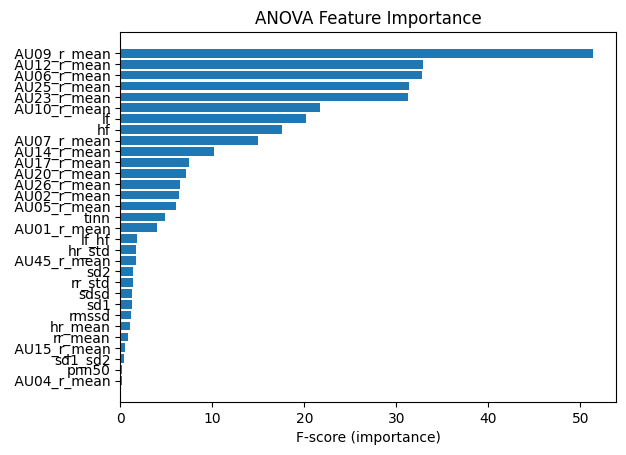

In [28]:
import matplotlib.pyplot as plt

# Sort again for plotting
names = [x[0] for x in anova_results]
f_scores = [x[1] for x in anova_results]

plt.figure()
plt.barh(names, f_scores)
plt.xlabel("F-score (importance)")
plt.title("ANOVA Feature Importance")
plt.gca().invert_yaxis()
plt.show()